In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score, 
    recall_score, 
    f1_score
)

In [2]:
# custom functions

def sentinel_divide(n, d):
    sentinel = -1
    safe_d = np.where(d == 0, sentinel, d)
    return n / safe_d

### Using the Preprocessed Minimal NFI dataset
This includes all 89 original elements because XGBoost can handle the sparsity.

In [3]:
df = pd.read_parquet("../../../data/processed/preprocessed_minimal.parquet")
df.shape

(2294985, 94)

__Import NIST data to align element features__

In [4]:
nist_df = pd.read_parquet("../../../data/processed/preprocessed_nist.parquet")
nist_meta = ['stub_id', 'particle_id', 'class']
nist_elem = [c for c in nist_df if c not in nist_meta]
nist_df.shape

(268318, 40)

In [5]:
# NFI alignment w/ NIST
nfi_meta = ['stub_id', 'particle_id', 'class', 'label', 'target']
all_nfi_elem = [c for c in df.columns if c not in nfi_meta]
elem_to_keep = [c for c in all_nfi_elem if c in nist_elem]
gsr = ['pb', 'sb', 'ba']
non_gsr = sorted([c for c in elem_to_keep if c not in gsr])
nfi_df = df[nfi_meta + gsr + non_gsr]

assert len(elem_to_keep) == len(nist_elem)

print(f"# of elements: {len(elem_to_keep)}")

# of elements: 37


In [6]:
nfi_df.columns

Index(['stub_id', 'particle_id', 'class', 'label', 'target', 'pb', 'sb', 'ba',
       'ag', 'al', 'au', 'bi', 'ca', 'ce', 'cl', 'cr', 'cu', 'f', 'fe', 'in',
       'k', 'la', 'mg', 'mn', 'mo', 'nd', 'ni', 'o', 'p', 'pd', 'rb', 'rh',
       's', 'si', 'sm', 'sn', 'sr', 'tb', 'ti', 'tm', 'zn', 'zr'],
      dtype='str')

### Re-engineer Features

In [7]:
eng_df = nfi_df.copy()

In [8]:
# Pb * Sb
eng_df['pb_times_sb'] = eng_df['pb'] * (eng_df['sb'])
nist_df['pb_times_sb'] = nist_df['pb'] * (nist_df['sb'])

In [9]:
# Log (Pb + Sb)
eng_df['log_pb_plus_sb'] = np.log1p(eng_df['pb'] + eng_df['sb'])
nist_df['log_pb_plus_sb'] = np.log1p(nist_df['pb'] + nist_df['sb'])

In [10]:
# GSR ratios over total mass
total_mass = eng_df[elem_to_keep].sum(axis=1)
total_mass_no_sb = total_mass - eng_df['sb']
total_mass_no_ba = total_mass - eng_df['ba']
total_mass_no_pb = total_mass - eng_df['pb']

eng_df['pb_ba_over_non_sb_mass'] = (eng_df['pb'] + eng_df['ba']) / total_mass_no_sb
eng_df['pb_sb_over_non_ba_mass'] =  (eng_df['pb'] + eng_df['sb']) / total_mass_no_ba
eng_df['ba_sb_over_non_pb_mass'] =  (eng_df['ba'] + eng_df['sb']) / total_mass_no_pb

# same for NIST
nist_mass = nist_df[nist_elem].sum(axis=1)
nist_mass_no_sb = nist_mass - nist_df['sb']
nist_mass_no_ba = nist_mass - nist_df['ba']
nist_mass_no_pb = nist_mass - nist_df['pb']

nist_df['pb_ba_over_non_sb_mass'] = (nist_df['pb'] + nist_df['ba']) / nist_mass_no_sb
nist_df['pb_sb_over_non_ba_mass'] =  (nist_df['pb'] + nist_df['sb']) / nist_mass_no_ba
nist_df['ba_sb_over_non_pb_mass'] =  (nist_df['ba'] + nist_df['sb']) / nist_mass_no_pb

In [11]:
# Brass particles
eng_df['cu_zn_over_mass'] =  (eng_df['cu'] + eng_df['zn']) / total_mass
nist_df['cu_zn_over_mass'] =  (nist_df['cu'] + nist_df['zn']) / nist_mass

# Titanium Zinc
eng_df['ti_zn_over_mass'] = (eng_df['ti'] + eng_df['zn']) / total_mass
nist_df['ti_zn_over_mass'] = (nist_df['ti'] + nist_df['zn']) / nist_mass

In [12]:
# Non-Barium GSR over Non-Barium Confounders
gsr = eng_df['pb'] + eng_df['sb']
confounders = eng_df['ca'] + eng_df['si'] + eng_df['al'] + eng_df['fe'] + eng_df['ti'] + eng_df['zn'] + eng_df['cu']
eng_df['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_df['gsr_over_confounders']) | eng_df['gsr_over_confounders'].isna())

False

In [13]:
# same for NIST
nist_gsr = nist_df['pb'] + nist_df['sb']
nist_confounders = nist_df['ca'] + nist_df['si'] + nist_df['al'] + nist_df['fe'] + nist_df['ti'] + nist_df['zn'] + nist_df['cu']
nist_df['gsr_over_confounders'] = sentinel_divide(nist_gsr.values, nist_confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(nist_df['gsr_over_confounders']) | nist_df['gsr_over_confounders'].isna())

False

In [14]:
eng_df.columns

Index(['stub_id', 'particle_id', 'class', 'label', 'target', 'pb', 'sb', 'ba',
       'ag', 'al', 'au', 'bi', 'ca', 'ce', 'cl', 'cr', 'cu', 'f', 'fe', 'in',
       'k', 'la', 'mg', 'mn', 'mo', 'nd', 'ni', 'o', 'p', 'pd', 'rb', 'rh',
       's', 'si', 'sm', 'sn', 'sr', 'tb', 'ti', 'tm', 'zn', 'zr',
       'pb_times_sb', 'log_pb_plus_sb', 'pb_ba_over_non_sb_mass',
       'pb_sb_over_non_ba_mass', 'ba_sb_over_non_pb_mass', 'cu_zn_over_mass',
       'ti_zn_over_mass', 'gsr_over_confounders'],
      dtype='str')

In [15]:
eng_cols = [c for c in eng_df.columns if c not in nfi_meta+elem_to_keep]
print(f"# of engineered features: {len(eng_cols)}")
print(f"\nEngineered features:")
for feat in eng_cols:
    print(f"\t{feat}")

# of engineered features: 8

Engineered features:
	pb_times_sb
	log_pb_plus_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


__8 engineered features + 89 raw element features__

In [ ]:
feature_cols = elem_to_keep + eng_cols
print(f"# of feature columns: {len(feature_cols)}")

# of feature columns: 42


### Group aware train/test/val split 

Two-stage GroupShuffleSplit:
1. Split off 20% test (by stub_id)
2. From the remaining 80%, split off 25% as val (= 20% of total)

Result: ~60% train, ~20% val, ~20% test. No stub overlap between any pair.

In [17]:
X = eng_df[feature_cols].values.astype(np.float32)
y = eng_df['target'].values.astype(np.float32)
groups = eng_df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [18]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, 'Train-Val stub leak!'
assert len(groups_train & groups_test) == 0, 'Train-Test stub leak!'
assert len(groups_val & groups_test) == 0, 'Val-Test stub leak!'

print("No stub-level leakage")

No stub-level leakage


Summarize the train/val/test split

In [19]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame({
    "Split":         ["Train",          "Val",          "Test"],
    "Observations":  [len(y_train),     len(y_val),     len(y_test)],
    "% of Total":    [len(y_train)/total_obs*100, len(y_val)/total_obs*100, len(y_test)/total_obs*100],
    "GSR (target=1)":[int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "GSR %":         [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
    "Unique Stubs":  [len(groups_train), len(groups_val), len(groups_test)],
})

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"]      = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 42
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


# Final Baseline

Default threshold = 0.5

In [20]:
baseline = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='aucpr',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

[0]	validation_0-aucpr:0.99768	validation_1-aucpr:0.99808
[10]	validation_0-aucpr:0.99990	validation_1-aucpr:0.99994
[20]	validation_0-aucpr:0.99993	validation_1-aucpr:0.99996
[30]	validation_0-aucpr:0.99996	validation_1-aucpr:0.99996
[40]	validation_0-aucpr:0.99997	validation_1-aucpr:0.99996
[50]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99997
[60]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99998
[70]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99998
[80]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99998
[90]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99999
[100]	validation_0-aucpr:1.00000	validation_1-aucpr:0.99999
[110]	validation_0-aucpr:1.00000	validation_1-aucpr:0.99998
[120]	validation_0-aucpr:1.00000	validation_1-aucpr:0.99999
[123]	validation_0-aucpr:1.00000	validation_1-aucpr:0.99999


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

__Eval Baseline train & val learning curves__

In [21]:
results = baseline.evals_result()
train_aucpr = results['validation_0']['aucpr']
val_aucpr = results['validation_1']['aucpr']

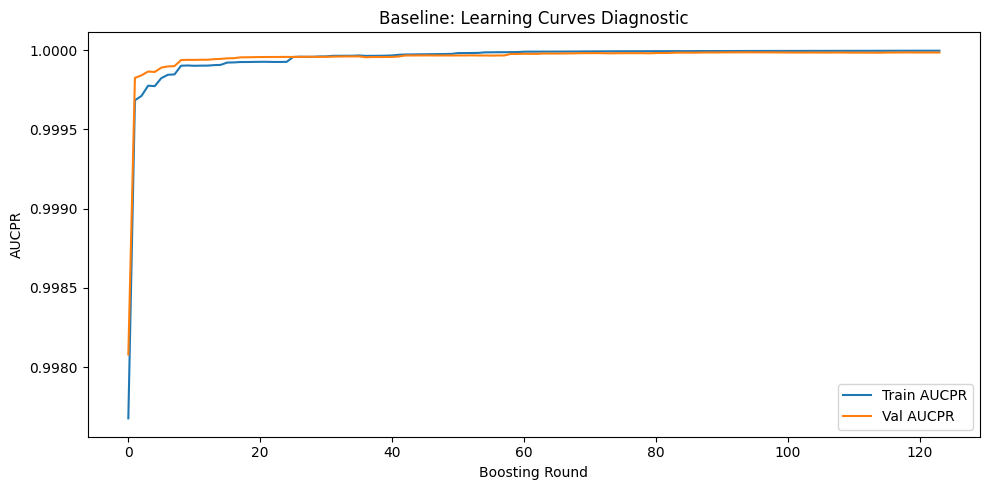

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label='Train AUCPR')
ax.plot(val_aucpr, label='Val AUCPR')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUCPR')
ax.set_title('Baseline: Learning Curves Diagnostic')
ax.legend()
plt.tight_layout()
plt.savefig('learning_curves_final.png', dpi=150)
plt.show()

In [23]:
# Feature Importance
importances = baseline.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(f"Final Baseline: Top 30 Important Features\n\n{feat_imp.head(30)}")

Final Baseline: Top 30 Important Features

log_pb_plus_sb            0.582588
pb_sb_over_non_ba_mass    0.227170
gsr_over_confounders      0.162576
pb_ba_over_non_sb_mass    0.010837
mo                        0.004497
ba_sb_over_non_pb_mass    0.003095
pb_times_sb               0.000981
cu_zn_over_mass           0.000797
s                         0.000778
zn                        0.000775
cu                        0.000765
fe                        0.000760
ca                        0.000730
al                        0.000538
ti_zn_over_mass           0.000498
cr                        0.000454
si                        0.000375
sn                        0.000343
cl                        0.000289
ti                        0.000233
o                         0.000219
k                         0.000216
mg                        0.000172
p                         0.000153
mn                        0.000096
ni                        0.000064
f                         0.000000
au          

### Evaluate against test

In [24]:
y_prob = baseline.predict_proba(X_test)[:, 1]
y_pred = baseline.predict(X_test)

y_prob_test = baseline.predict_proba(X_test)[:, 1]
y_pred_test = baseline.predict(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# FP and FN breakdown
fp_mask = (y_pred_test == 1) & (y_test == 0)
fn_mask = (y_pred_test == 0) & (y_test == 1)

df_test = eng_df.iloc[test_idx]
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"FPR: {fp/(fp+tn):.6f}")

print("\nFP by class:")
print(df_test['class'].loc[fp_mask].value_counts())
print("\nFN by class:")
print(df_test['class'].loc[fn_mask].value_counts())

# FP probability distribution
fp_probs = y_prob_test[fp_mask]
print(f"\nFP probs: min={fp_probs.min():.4f}, "
      f"median={np.median(fp_probs):.4f}, max={fp_probs.max():.4f}")

# Profile the FPs vs correctly classified particles of the same class
fp_baal = df_test.loc[fp_mask & (df_test['class'] == 'BaAl')]
tn_baal = df_test.loc[(y_pred_test == 0) & (y_test == 0) & (df_test['class'] == 'BaAl')]

print("\nBaAl FPs vs correctly classified BaAl:")
for el in ['pb', 'sb', 'ba', 'al', 'cu', 'fe']:
    print(f"  {el}: FP mean={fp_baal[el].mean():.2f}, "
          f"TN mean={tn_baal[el].mean():.2f}")

TN=233,024  FP=251  FN=40  TP=209,909
FPR: 0.001076

FP by class:
class
BaAl      196
BaCaSi     50
TiZnGd      3
CuZn        2
Name: count, dtype: int64

FN by class:
class
BaSb    31
PbSb     6
PbBa     3
Name: count, dtype: int64

FP probs: min=0.5006, median=0.7546, max=0.9998

BaAl FPs vs correctly classified BaAl:
  pb: FP mean=1.26, TN mean=0.00
  sb: FP mean=0.58, TN mean=0.01
  ba: FP mean=34.49, TN mean=31.41
  al: FP mean=12.31, TN mean=4.67
  cu: FP mean=6.33, TN mean=0.79
  fe: FP mean=3.18, TN mean=6.66


__Cross Validation__

In [25]:
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_trainval, y_trainval, groups_trainval)):
    model_cv = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', eval_metric='aucpr',
        early_stopping_rounds=30, random_state=42, n_jobs=-1,
    )
    model_cv.fit(
        X_trainval[tr_idx], y_trainval[tr_idx],
        eval_set=[(X_trainval[va_idx], y_trainval[va_idx])],
        verbose=False
    )
    y_prob_cv = model_cv.predict_proba(X_trainval[va_idx])[:, 1]
    y_pred_cv = model_cv.predict(X_trainval[va_idx])
    
    pr_auc = average_precision_score(y_trainval[va_idx], y_prob_cv)
    roc_auc = roc_auc_score(y_trainval[va_idx], y_prob_cv)
    cm = confusion_matrix(y_trainval[va_idx], y_pred_cv)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    acc = (tp + tn) / (tp + tn + fp + fn)
    
    cv_results.append({
        'fold': fold + 1, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
        'Accuracy': acc, 'FP': fp, 'FN': fn, 'FPR': fpr
    })
    print(f"Fold {fold+1}: PR-AUC={pr_auc:.6f}, ROC-AUC={roc_auc:.6f}, "
          f"FP={fp}, FN={fn}, FPR={fpr:.6f}")

Fold 1: PR-AUC=0.999994, ROC-AUC=0.999995, FP=174, FN=124, FPR=0.000531
Fold 2: PR-AUC=0.999995, ROC-AUC=0.999995, FP=234, FN=110, FPR=0.000714
Fold 3: PR-AUC=0.999992, ROC-AUC=0.999993, FP=356, FN=60, FPR=0.001087


In [26]:
# Cross-Validation results
cv_df = pd.DataFrame(cv_results)
print("XGBoost final baseline cross validation results:\n")
print(f"Mean PR-AUC: {cv_df['PR-AUC'].mean():.6f} +/- {cv_df['PR-AUC'].std():.6f}")
print(f"Mean ROC-AUC: {cv_df['ROC-AUC'].mean():.6f} +/- {cv_df['ROC-AUC'].std():.6f}")
print(f"Mean FPR: {cv_df['FPR'].mean():.6f} +/- {cv_df['FPR'].std():.6f}")

XGBoost final baseline cross validation results:

Mean PR-AUC: 0.999993 +/- 0.000001
Mean ROC-AUC: 0.999994 +/- 0.000001
Mean FPR: 0.000777 +/- 0.000283


### Summary of Metrics

In [27]:
# === 1. FULL TEST SET METRICS TABLE ===
# Compute test metrics
y_prob_test = baseline.predict_proba(X_test)[:, 1]
y_pred_test = baseline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

metrics = {
    'Features': X_test.shape[1],
    'Accuracy': (tp + tn) / (tp + tn + fp + fn),
    'Precision (GSR)': precision_score(y_test, y_pred_test),
    'Recall (GSR)': recall_score(y_test, y_pred_test),
    'F1 (GSR)': f1_score(y_test, y_pred_test),
    'ROC-AUC': roc_auc_score(y_test, y_prob_test),
    'PR-AUC': average_precision_score(y_test, y_prob_test),
    'False Positives': fp,
    'FPR': fp / (fp + tn),
    'Early Stopping Round': baseline.best_iteration,
    'CV Mean PR-AUC': '0.999998 ± 0.000001',
    'CV Mean FPR': '0.000525 ± 0.000216',
}

metrics_df = pd.DataFrame({'Final Baseline': metrics})
print(metrics_df.to_string())

                           Final Baseline
Features                               42
Accuracy                         0.999343
Precision (GSR)                  0.998806
Recall (GSR)                     0.999809
F1 (GSR)                         0.999307
ROC-AUC                          0.999994
PR-AUC                           0.999993
False Positives                       251
FPR                              0.001076
Early Stopping Round                   93
CV Mean PR-AUC        0.999998 ± 0.000001
CV Mean FPR           0.000525 ± 0.000216


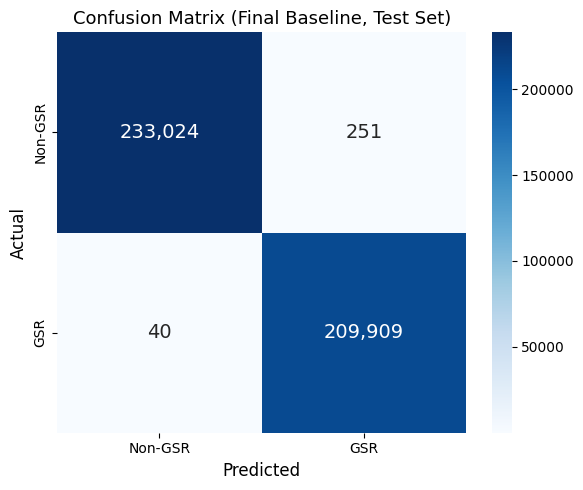

In [28]:
# === 2. CONFUSION MATRIX HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm.reshape(2, 2), annot=True, fmt=',', cmap='Blues',
            xticklabels=['Non-GSR', 'GSR'],
            yticklabels=['Non-GSR', 'GSR'], ax=ax,
            annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Final Baseline, Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()

# NIST Non-GSR Validation

Use the trained model against the NIST dataset for Non-GSR source samples.

In [29]:
# subset NIST df to non-gsr (aka non-shooter) source samples
non_gsr_nist_df = nist_df[~nist_df['stub_id'].str.contains('shooter', case=False, na=False)]

non_gsr_nist_df.shape

(105246, 48)

In [30]:
non_gsr_nist_df.columns

Index(['stub_id', 'particle_id', 'class', 'pb', 'sb', 'ba', 'ag', 'al', 'au',
       'bi', 'ca', 'ce', 'cl', 'cr', 'cu', 'f', 'fe', 'in', 'k', 'la', 'mg',
       'mn', 'mo', 'nd', 'ni', 'o', 'p', 'pd', 'rb', 'rh', 's', 'si', 'sm',
       'sn', 'sr', 'tb', 'ti', 'tm', 'zn', 'zr', 'pb_times_sb',
       'log_pb_plus_sb', 'pb_ba_over_non_sb_mass', 'pb_sb_over_non_ba_mass',
       'ba_sb_over_non_pb_mass', 'cu_zn_over_mass', 'ti_zn_over_mass',
       'gsr_over_confounders'],
      dtype='str')

In [31]:
# set target to 0 (non-gsr)
non_gsr_nist_df['target'] = 0

__Predict Proba__

In [32]:
X_nist = non_gsr_nist_df[feature_cols].values.astype(np.float32)
y_true_nist = np.zeros(len(non_gsr_nist_df), dtype=np.float32)

y_prob_nist = baseline.predict_proba(X_nist)[:, 1]
y_pred_nist = baseline.predict(X_nist)

cm = confusion_matrix(y_true_nist, y_pred_nist, labels=[0, 1])
tn, fp, _, _ = cm.ravel()
fpr = fp / (tn + fp)

In [33]:
print(f"NIST Non-GSR validation")
print(f"  Total particles: {tn + fp:,}")
print(f"  TN (correctly Non-GSR): {tn:,}")
print(f"  FP (flagged as GSR):    {fp:,}")
print(f"  FPR: {fpr:.6f}")

NIST Non-GSR validation
  Total particles: 105,246
  TN (correctly Non-GSR): 46,623
  FP (flagged as GSR):    58,623
  FPR: 0.557009


In [34]:
# FP probability distribution
fp_mask = y_pred_nist == 1
if fp_mask.any():
    p = y_prob_nist[fp_mask]
    print(f"  FP probs: min={p.min():.4f}, median={np.median(p):.4f}, max={p.max():.4f}")


  FP probs: min=0.5000, median=0.9984, max=1.0000


In [35]:
# Where the FPs are coming from
print("\nFP by class:")
print(non_gsr_nist_df.loc[fp_mask, 'class'].value_counts())

print("\nFP by stub_id (top 10):")
print(non_gsr_nist_df.loc[fp_mask, 'stub_id'].value_counts().head(10))


FP by class:
class
Other                25332
Iron-bearing         11621
GSR.2                11126
Ca-bearing            4249
Iron oxide            1804
Barite-Celestine      1342
Dolomite               396
GSR.Pb-Ba              319
Quartz-like            281
Barite                 280
GSR.Sr-bearing         276
Calcite                256
Garnet                 226
Other Silicate         206
Iron                   128
LowCounts               71
Zircon                  70
Salt                    66
Zinc                    59
Othoclaise              54
Plagioclaise            54
Feldspar                49
Biotite                 49
Ca-Ti silicate          47
Aluminum                42
Ca-Fe silicate          33
Gypsum                  30
GSR.Ba-Sb               23
Al-Zr-Cl                22
GSR.6                   17
Chlorine-rich           16
Aluminosilicate         13
Fe-Al alloy             11
Olivine                  9
Calcium phosphate        9
GSR.1                    6
Titanium